In [1]:
%reload_ext autoreload
%autoreload 2
import os
from pathlib import Path
import sys
from typing import Any, Literal, Optional

from frozendict import frozendict
from qecbench import TaskStats

# Add parent directory to the path
sys.path.insert(0, os.path.abspath(".."))

# Register learned decoders so they can be instantiated by `qecdec.decoders.create_decoder`.
import learned_decoders  # noqa: F401
from utils import get_csv_path

In [2]:
import matplotlib.pyplot as plt

import plot_utils

%matplotlib inline
plt.rcParams.update({"figure.figsize": (10, 6), "font.size": 12, "pdf.fonttype": 42})

In [3]:
LIST_NUM_CHAINS = [1, 2, 4]
LIST_NUM_RELAYS = [1, 2, 4, 8, 16]

# Helper functions

In [4]:
def load_stats(
    *,
    circuit_name: str,
    circuit_params: dict[str, Any],
    decoder_name: str,
    error_rates: list[float],
    decoder_fixed_params: dict[str, Any],
    decoder_flex_params: dict[str, list[Any]],
) -> list[TaskStats]:
    csv_path = get_csv_path(circuit_name, circuit_params, decoder_name)
    filtered_stats: list[TaskStats] = []
    for s in TaskStats.load_csv(csv_path):
        m = s.metadata
        if m.error_rate not in error_rates:
            continue
        p = m.decoder_params
        if not all(p[k] == v for k, v in decoder_fixed_params.items()):
            continue
        if not all(p[k] in v_list for k, v_list in decoder_flex_params.items()):
            continue
        filtered_stats.append(s)
    return filtered_stats


In [5]:
def plot_fr_vs_iter_budget(
    stats: list[TaskStats],
    *,
    x_metric: Literal["iter_budget", "avg_iter"],
    y_metric: Literal["fr_per_shot", "fr_per_round"],
    suptitle: Optional[str] = None,
    save_at: Optional[str | Path] = None,
):
    def group_fn(s: TaskStats) -> frozendict[str, str | int]:
        m = s.metadata
        assert m.decoder_name in ["MultiRelayBP", "LearnedMultiRelayBP"]
        return frozendict(
            {
                "decoder_name": m.decoder_name,
                "stop_nconv": m.decoder_params["stop_nconv"],
                "num_chains": m.decoder_params["num_chains"],
            }
        )

    def label_fn(id: frozendict[str, str | int]) -> str:
        return ", ".join(
            [
                id["decoder_name"],
                f"#solns={id['stop_nconv']}",
                f"#chains={id['num_chains']}",
            ]
        )

    def marker_fn(id: frozendict[str, str | int]) -> str:
        if id["stop_nconv"] == 1:
            return "o"
        elif id["stop_nconv"] == 2:
            return "^"
        else:
            raise NotImplementedError

    def linestyle_fn(id: frozendict[str, str | int]) -> str:
        if id["decoder_name"] == "MultiRelayBP":
            return "-"
        elif id["decoder_name"] == "LearnedMultiRelayBP":
            return "--"
        else:
            raise NotImplementedError

    _colors: list[str] = plt.rcParams["axes.prop_cycle"].by_key()["color"]
    num_chains_to_color: dict[int, str] = {
        num_chain: _colors[i % len(_colors)]
        for i, num_chain in enumerate(LIST_NUM_CHAINS)
    }

    fig, ax = plt.subplots()
    plot_utils.plot_fr_vs_iter_budget_from_collected(
        stats,
        ax,
        x_metric=x_metric,
        y_metric=y_metric,
        group_fn=group_fn,
        label_fn=label_fn,
        marker_fn=marker_fn,
        color_fn=lambda id: num_chains_to_color[id["num_chains"]],
        linestyle_fn=linestyle_fn,
        xscale="linear",
        yscale="log",
    )
    if suptitle:
        fig.suptitle(suptitle, fontsize=plot_utils.SUPTITLE_FONTSIZE)
    fig.tight_layout()
    if save_at:
        fig.savefig(save_at)
    plt.show()


# RotatedSurfaceCode_Circuit, basis=Z, d=11, rounds=11, error_rate=0.001

Loaded 29 entries


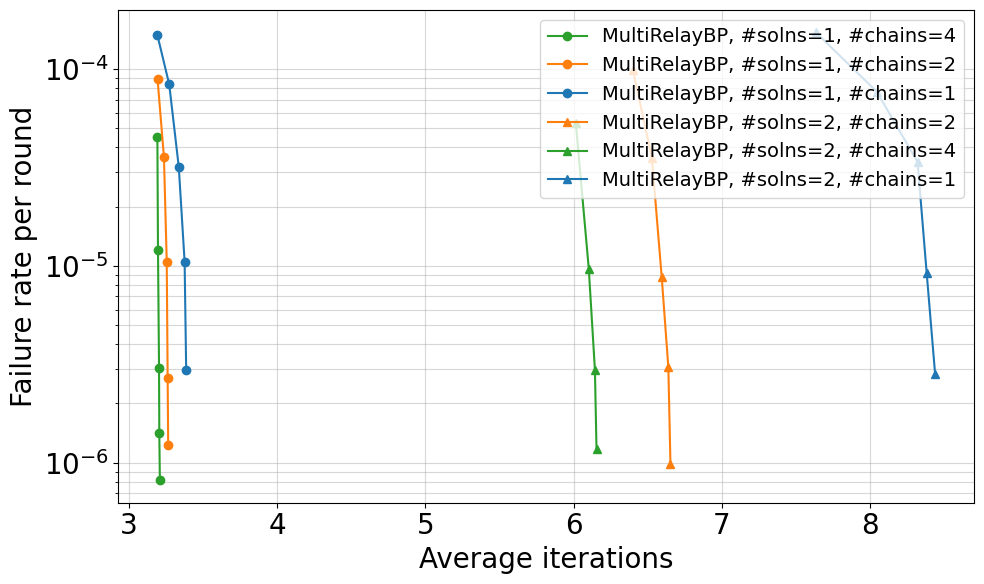

In [6]:
circuit_name = "RotatedSurfaceCode_Circuit"
circuit_params = {"basis": "Z", "d": 11, "rounds": 11}
error_rates = [0.001]

multirelaybp_fixed_params = {
    "gamma0": 0.55,
    "gamma_dist_interval": (-0.2944735403909491, 0.9444054073490704),
    "pre_iter": 50,
    "max_iter_per_relay": 50,
}
decoder_flex_params = {
    "stop_nconv": [1, 2],
    "num_chains": LIST_NUM_CHAINS,
    "num_relays": LIST_NUM_RELAYS,
}
loaded_stats = load_stats(
    circuit_name=circuit_name,
    circuit_params=circuit_params,
    decoder_name="MultiRelayBP",
    error_rates=error_rates,
    decoder_fixed_params=multirelaybp_fixed_params,
    decoder_flex_params=decoder_flex_params,
)
print(f"Loaded {len(loaded_stats)} entries")

plot_fr_vs_iter_budget(
    loaded_stats,
    # x_metric="iter_budget",
    x_metric="avg_iter",
    y_metric="fr_per_round",
)


# RotatedSurfaceCode_Phenom, basis=Z, d=11, rounds=11, error_rate=0.005

Loaded 60 entries


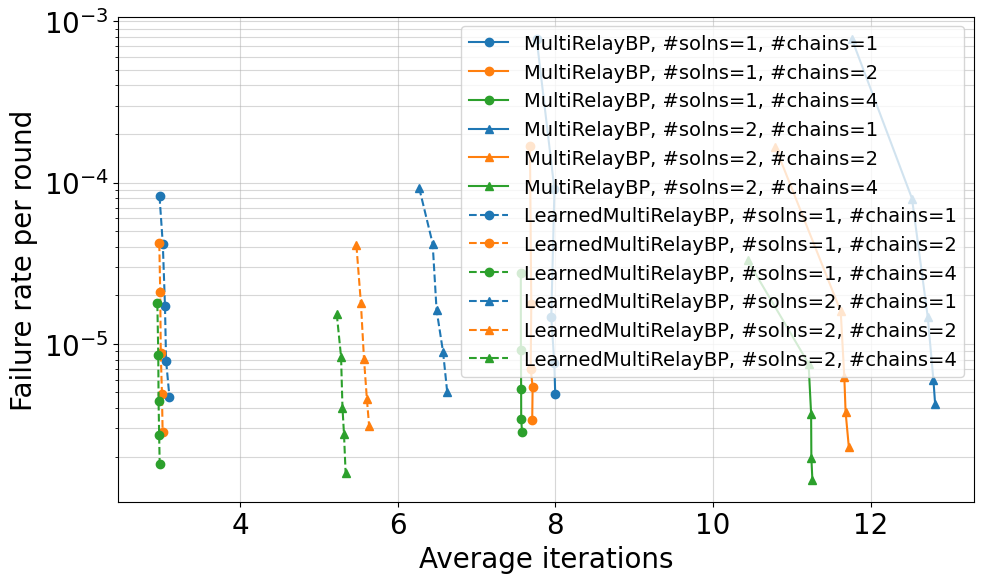

In [7]:
circuit_name = "RotatedSurfaceCode_Phenom"
circuit_params = {"basis": "Z", "d": 11, "rounds": 11}
error_rates = [0.005]
ckpt_rel_path = "torchdecoder/runs/RotatedSurfaceCode_Phenom/basis=Z_d=11_rounds=11/LearnedDMemBP/run_0/checkpoints/best_model.ckpt"

multirelaybp_fixed_params = {
    "gamma0": 0.65,
    "gamma_dist_interval": (-0.2241259276391633, 0.5608805426310253),
    "pre_iter": 50,
    "max_iter_per_relay": 50,
}
learned_multirelaybp_fixed_params = {
    "ckpt_rel_path": ckpt_rel_path,
    "gamma_dist_interval": (-0.2241259276391633, 0.5608805426310253),
    "pre_iter": 50,
    "max_iter_per_relay": 50,
}
decoder_flex_params = {
    "stop_nconv": [1, 2],
    "num_chains": LIST_NUM_CHAINS,
    "num_relays": LIST_NUM_RELAYS,
}
loaded_stats = load_stats(
    circuit_name=circuit_name,
    circuit_params=circuit_params,
    decoder_name="MultiRelayBP",
    error_rates=error_rates,
    decoder_fixed_params=multirelaybp_fixed_params,
    decoder_flex_params=decoder_flex_params,
) + load_stats(
    circuit_name=circuit_name,
    circuit_params=circuit_params,
    decoder_name="LearnedMultiRelayBP",
    error_rates=error_rates,
    decoder_fixed_params=learned_multirelaybp_fixed_params,
    decoder_flex_params=decoder_flex_params,
)
print(f"Loaded {len(loaded_stats)} entries")

plot_fr_vs_iter_budget(
    loaded_stats,
    # x_metric="iter_budget",
    x_metric="avg_iter",
    y_metric="fr_per_round",
)
